### Minicurso Sistemas Multi-agente com LangGraph

## Grafo com Loop

Moacir Antonelli Ponti - 2025


---

In [33]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
import random

In [39]:
class AgentState(TypedDict):
    values: List[int]
    counter: int
    message: str
    total_numbers: int

def initialize_node(state: AgentState) -> AgentState:
    state['message'] = "Iniciando..."
    state['counter'] = 0
    state['values'] = []
    
    if state['total_numbers'] < 1:
        #state['total_numbers'] = 1
        #print('total_numbers must be at least 1, defaulting to 1.')
        raise ValueError('total_numbers must be at least 1')

    print(state['message'])
    return state

def random_generator_node(state: AgentState) -> AgentState:
    state['counter'] += 1
    state['values'].append(random.randint(1,100))
    return state

def end_node(state: AgentState) -> AgentState:
    state['message'] = "Fim do processamento"
    state['message'] += f" com {len(state['values'])} valores gerados"
    print(state['message'])
    return state

def loop_decision_function(state: AgentState) -> str:
    if state['counter'] < state['total_numbers']:
        return "LOOP"
    else:
        return "STOP"

In [40]:
graph = StateGraph(AgentState)

graph.add_node(node="initialize", action=initialize_node)
graph.add_node(node="random_generation", action=random_generator_node)
graph.add_node(node="end_process", action=end_node)

graph.add_conditional_edges(
    source="random_generation",
    path=loop_decision_function,
    path_map={
        "LOOP": "random_generation",
        "STOP": "end_process"
    }
)

graph.set_entry_point("initialize") # graph.add_edge(START, "initialize")
graph.add_edge("initialize", "random_generation")
graph.add_edge("end_process", END)

app = graph.compile()

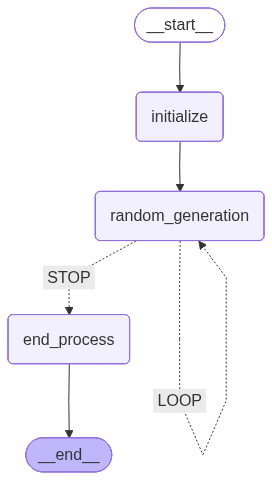

In [41]:
display(Image(app.get_graph().draw_mermaid_png()))

In [42]:
res = app.invoke({'total_numbers': 7})
print(res['values'])

Iniciando...
Fim do processamento com 7 valores gerados
[95, 8, 97, 41, 93, 60, 21]


In [43]:
res = app.invoke({'total_numbers': -2})
print(res['values'])

ValueError: total_numbers must be at least 1

## Exercício: 

Implemente um agente que simule um processo de refinamento paramétrico de um valor ao longo de ciclos.
Inicializar o valor com 1 e, a cada ciclo, multiplicar esse valor por `x` e somar um valor `y` ao resultado.

v1 =  1*x + y</br>
v2 = v1*x + y</br>
..</br>
vn = v(n-1)*x + y</br>

Tanto `x` quanto `y` devem ser inicializados aleatoriamente com valores entre 1 e 4.

O processo finaliza quando o valor atingir um limiar (passado na entrada ao invocar o agente) ou quando completar 10 ciclos máximos.

In [51]:
class AgentState(TypedDict):
    result : float
    x : float
    y : float
    limiar : float
    ciclos: int
    status: str

def inicializa(state: AgentState) -> AgentState:
    state['result'] = 1
    state['ciclos'] = 0

    state['x'] = random.randint(1,4)
    state['y'] = random.randint(1,4)

    if "limiar" not in state:
        raise ValueError("É necessário fornecer um limiar como entrada")
    
    state["status"] = f"Inicio do processo: x={state['x']}, y={state['y']}, limiar={state['limiar']}"
    print(state['status'])
    return state

def refina(state: AgentState) -> AgentState:
    state['ciclos'] += 1
    x = state['x']
    y = state['y']
    state['result'] =  state['result'] * x + y
    return state

def decisao(state: AgentState) -> str:
    # condicoes de parada
    if state["result"] >= state["limiar"] or state["ciclos"] >= 10:
        return "PARA"
    
    return "CONTINUA"

def finaliza(state: AgentState) -> AgentState:
    state["status"] = (
        f"Processo finalizado com valor={state['result']} "
        f"após {state['ciclos']} ciclos "
        f"com x={state['x']} e y={state['y']}."
    )
    print(state['status'])
    return state

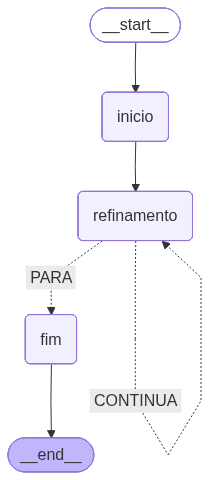

In [52]:
graph = StateGraph(AgentState)

graph.add_node("inicio", inicializa)
graph.add_node("refinamento", refina)
graph.add_node("fim", finaliza)

graph.set_entry_point("inicio")
graph.add_edge("inicio", "refinamento")

graph.add_conditional_edges(
    source="refinamento",
    path=decisao,
    path_map={"CONTINUA": "refinamento", "PARA": "fim"}
)

graph.add_edge("fim", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
res = app.invoke({"limiar": 150})

Inicio do processo: x=2, y=3, limiar=150
Processo finalizado com valor=253 após 6 ciclos com x=2 e y=3.


In [54]:
res = app.invoke({"limiar": -1})

Inicio do processo: x=2, y=2, limiar=-1
Processo finalizado com valor=4 após 1 ciclos com x=2 e y=2.


In [55]:
res = app.invoke({"limiar": 0})

Inicio do processo: x=4, y=3, limiar=0
Processo finalizado com valor=7 após 1 ciclos com x=4 e y=3.


In [56]:
res = app.invoke({"limiar": 1000})

Inicio do processo: x=2, y=2, limiar=1000
Processo finalizado com valor=1534 após 9 ciclos com x=2 e y=2.


In [ ]:
import random
from typing import TypedDict
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    valor: int
    ciclos: int
    x: int
    y: int
    limiar: int
    status: str

def inicializa(state: AgentState) -> AgentState:
    state["valor"] = 1
    state["ciclos"] = 0

    # parâmetros gerados aleatoriamente entre 1 e 4
    state["x"] = random.randint(1, 4)
    state["y"] = random.randint(1, 4)

    # limiar deve vir de fora
    if "limiar" not in state:
        raise ValueError("É necessário fornecer o 'limiar' na entrada do agente.")

    state["status"] = (
        f"Início do processo: x={state['x']}, y={state['y']}, limiar={state['limiar']}"
    )
    print(state["status"])
    return state


def refina(state: AgentState) -> AgentState:
    state["ciclos"] += 1
    x = state["x"]
    y = state["y"]

    state["valor"] = state["valor"] * x + y
    return state


def decisao(state: AgentState) -> str:
    # condição de parada
    if state["valor"] >= state["limiar"]:
        return "PARA"
    if state["ciclos"] >= 10:
        return "PARA"

    return "CONTINUA"


def finaliza(state: AgentState) -> AgentState:
    state["status"] = (
        f"Processo finalizado com valor={state['valor']} "
        f"após {state['ciclos']} ciclos "
        f"(x={state['x']}, y={state['y']})."
    )
    print(state["status"])
    return state


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("inicio", inicializa)
graph.add_node("refinamento", refina)
graph.add_node("fim", finaliza)

graph.set_entry_point("inicio")
graph.add_edge("inicio", "refinamento")

graph.add_conditional_edges(
    source="refinamento",
    path=decisao,
    path_map={"CONTINUA": "refinamento", "PARA": "fim"}
)

graph.add_edge("fim", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
app.invoke({"limiar": 150})